In [1]:
library(Seurat)

library(ggplot2)
library(patchwork)
library(data.table)

Attaching SeuratObject

‘SeuratObject’ was built with package ‘Matrix’ 1.6.1.1 but the current
version is 1.6.4; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode



In [2]:
fread("../../SLE_dataset/metadata.csv")[,.N,by=c("condition","age")]

condition,age,N
<chr>,<chr>,<int>
SL,c,33
HD,c,11
HD,a,5
SL,a,7


Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with da

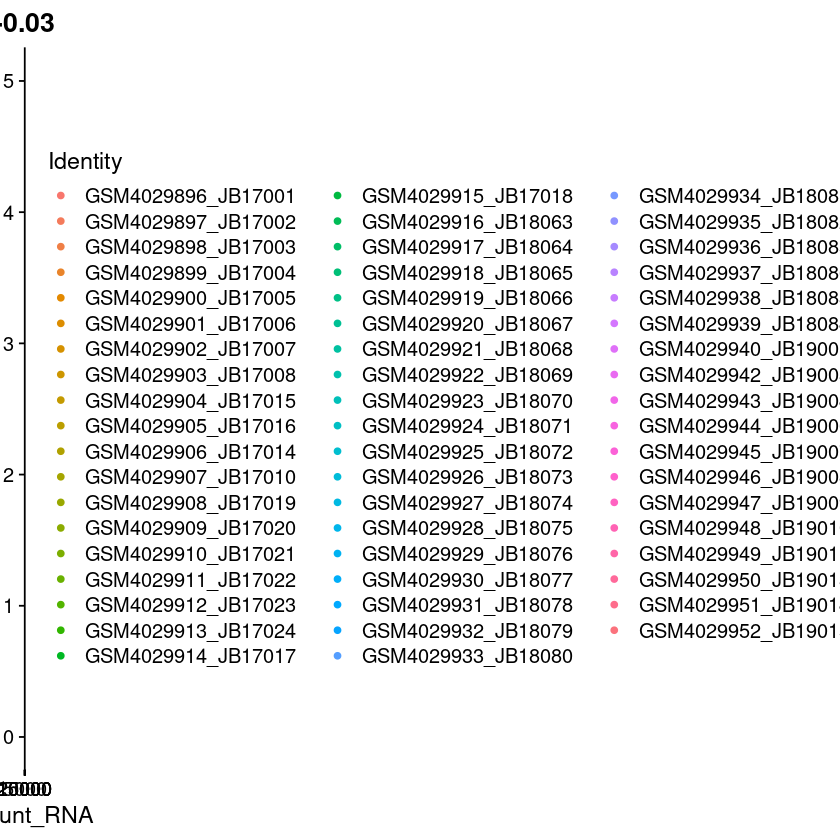

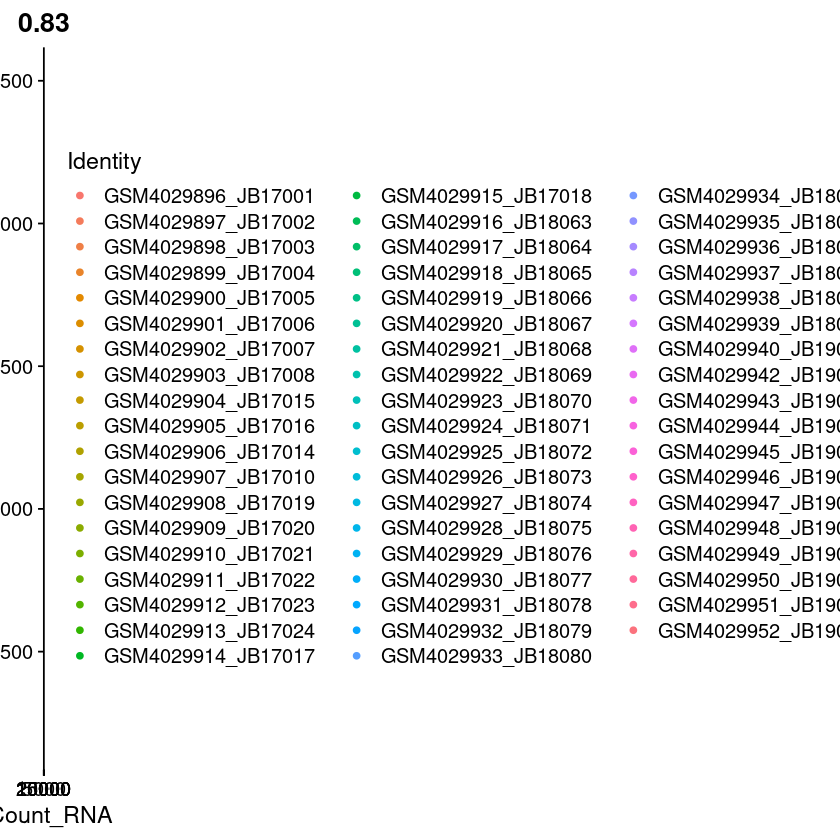

In [10]:
# get all folders in samples directory
data_path <- "../../SLE_dataset/samples/"
sample_dirs <- list.dirs(data_path, recursive = FALSE)

# read each sample and create a Seurat object
seurat_objects <- lapply(sample_dirs, function(dir) {
  data <- Read10X(data.dir = dir)
  seurat_obj <- CreateSeuratObject(counts = data, project = basename(dir))
  return(seurat_obj)
})

# merge all Seurat objects into one
seurat_obj_merged <- Reduce(function(x, y) merge(x, y), seurat_objects)
seurat_obj_merged[["percent.mt"]] <- PercentageFeatureSet(seurat_obj_merged, pattern = "^MT-")
seurat_obj_filtered <- subset(seurat_obj_merged, subset = nFeature_RNA > 200 & nFeature_RNA < 2500 & percent.mt < 5)
plot1 <- FeatureScatter(seurat_obj_filtered, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot2 <- FeatureScatter(seurat_obj_filtered, feature1 = "nCount_RNA",
                        feature2 = "nFeature_RNA")
plot1
plot2

In [15]:
# save filtered and non filtered objects
saveRDS(seurat_obj_merged, file = "../data/seurat_obj_merged.rds")
saveRDS(seurat_obj_filtered, file = "../data/seurat_obj_filtered.rds")

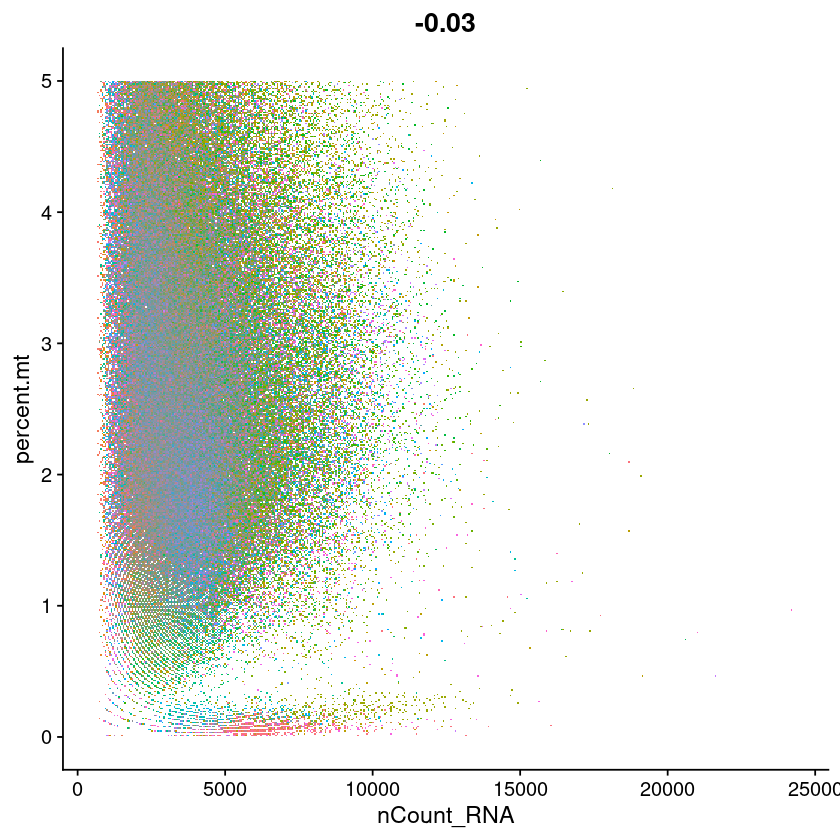

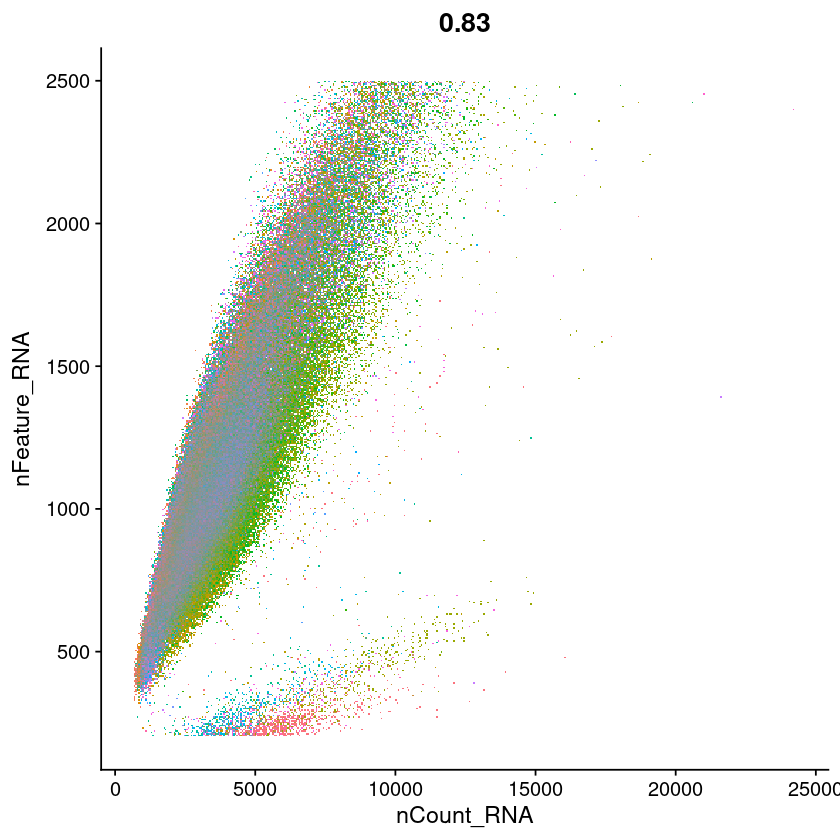

In [14]:
# plot seurat_obj_filtered without legend
plot1 <- FeatureScatter(seurat_obj_filtered, feature1 = "nCount_RNA", feature2 = "percent.mt") + NoLegend()
plot1

plot2 <- FeatureScatter(seurat_obj_filtered, feature1 = "nCount_RNA",
                        feature2 = "nFeature_RNA") + NoLegend()
plot2


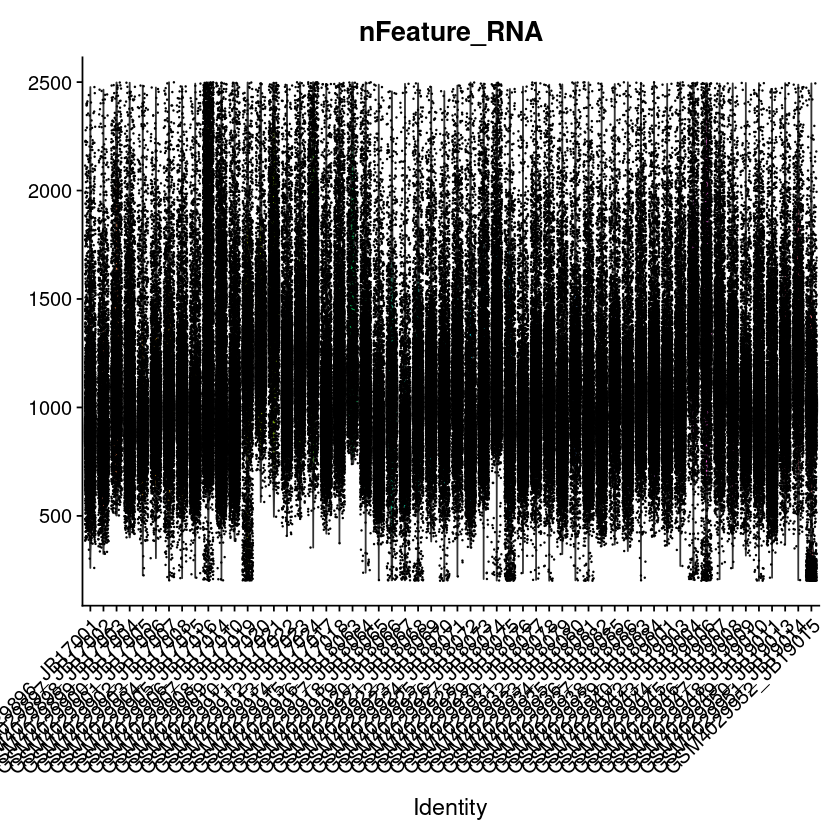

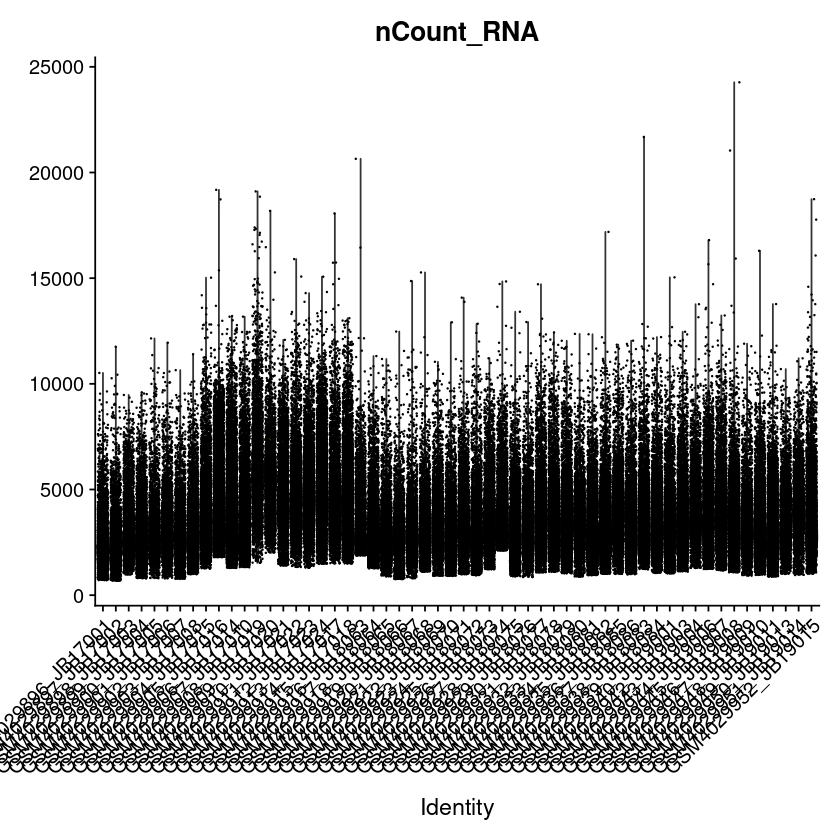

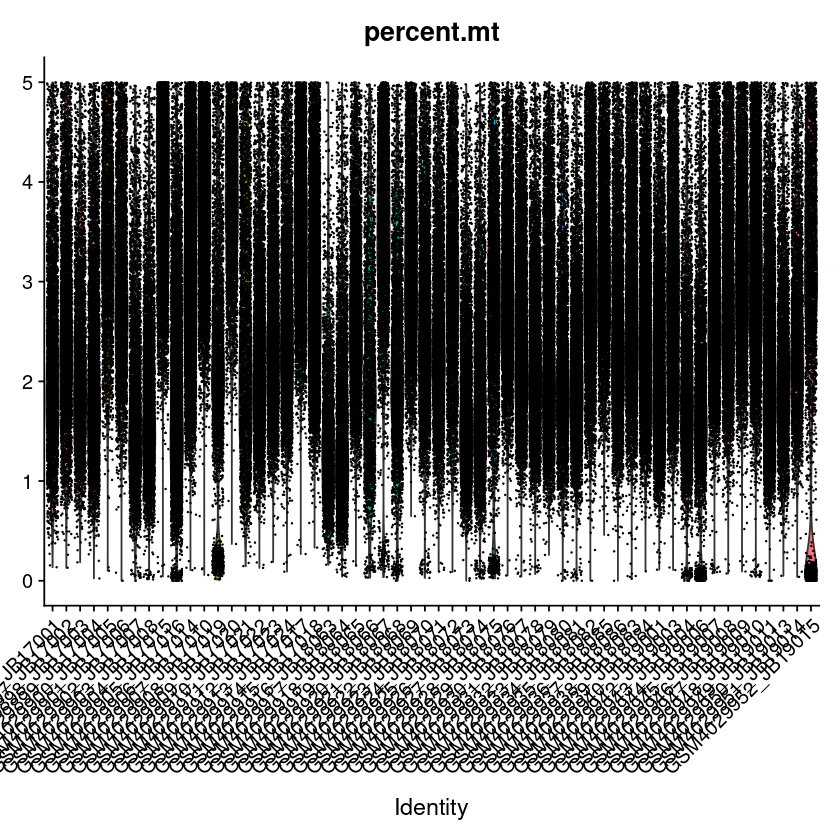

In [18]:
# visualize QC metrics as violin plots
# VlnPlot(seurat_obj_filtered, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)

VlnPlot(seurat_obj_filtered, features = c("nFeature_RNA"), ncol = 1) + NoLegend()
VlnPlot(seurat_obj_filtered, features = c("nCount_RNA"), ncol = 1) + NoLegend()
VlnPlot(seurat_obj_filtered, features = c("percent.mt"), ncol = 1) + NoLegend()

In [3]:
data_path <- "../../SLE_dataset/samples/GSM4029952_JB19015"

data <- Read10X(data.dir = data_path)

seurat_obj <- CreateSeuratObject(counts = data, project = "GSM4029952")

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


Initial number of cells: 6249 
Number of cells after filtering: 3869 
Percentage of cells retained: 61.91 %


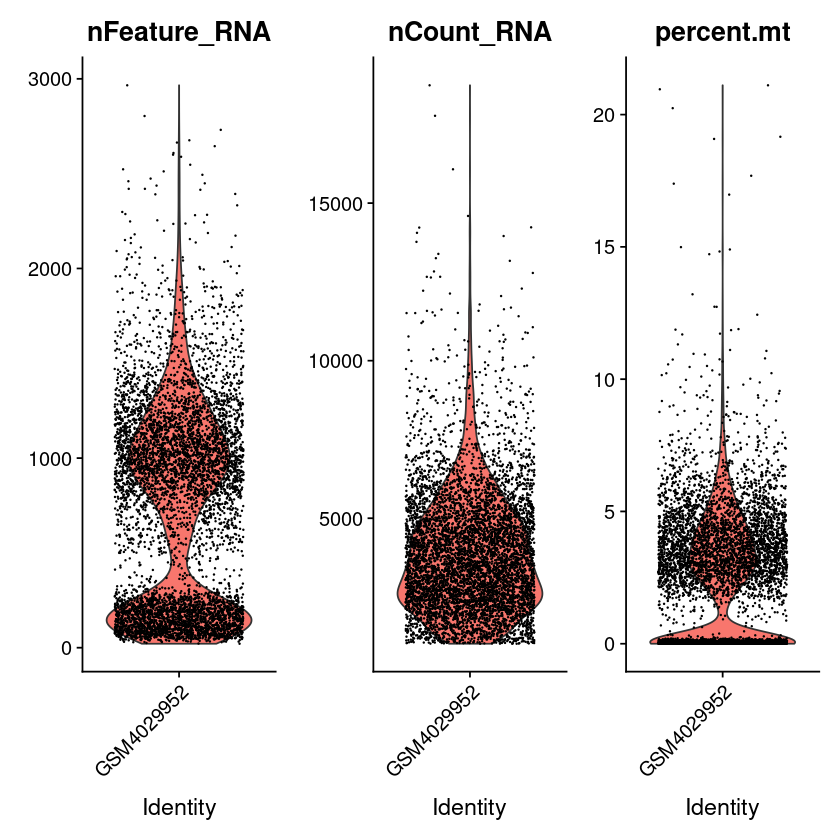

In [4]:
# Calculate mitochondrial percentage
# Assuming we're working with human data (adjust pattern if needed for other species)
seurat_obj[["percent.mt"]] <- PercentageFeatureSet(seurat_obj, pattern = "^MT-")

# If the above doesn't work (no MT genes found), try alternative patterns:
# seurat_obj[["percent.mt"]] <- PercentageFeatureSet(seurat_obj, pattern = "^mt-") # mouse
# seurat_obj[["percent.mt"]] <- PercentageFeatureSet(seurat_obj, pattern = "^Mt-") # alternative

# Check initial cell count
initial_cells <- ncol(seurat_obj)
cat("Initial number of cells:", initial_cells, "\n")

# Apply quality control filters
seurat_obj_filtered <- subset(seurat_obj,
                             subset = nFeature_RNA > 400 & 
                                     nFeature_RNA < 3000 & 
                                     percent.mt < 10)

# Get filtered cell count
filtered_cells <- ncol(seurat_obj_filtered)
cat("Number of cells after filtering:", filtered_cells, "\n")

# Calculate percentage of cells retained
retention_rate <- (filtered_cells / initial_cells) * 100
cat("Percentage of cells retained:", round(retention_rate, 2), "%\n")

# Optional: Visualize QC metrics before filtering
VlnPlot(seurat_obj, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)


In [5]:
qc_stats <- data.frame(
  total_cells = initial_cells,
  low_genes = sum(seurat_obj$nFeature_RNA <= 200),
  high_genes = sum(seurat_obj$nFeature_RNA >= 3000),
  high_mito = sum(seurat_obj$percent.mt >= 10),
  remaining_cells = filtered_cells
)

print(qc_stats)

  total_cells low_genes high_genes high_mito remaining_cells
1        6249      1694          0        40            3869


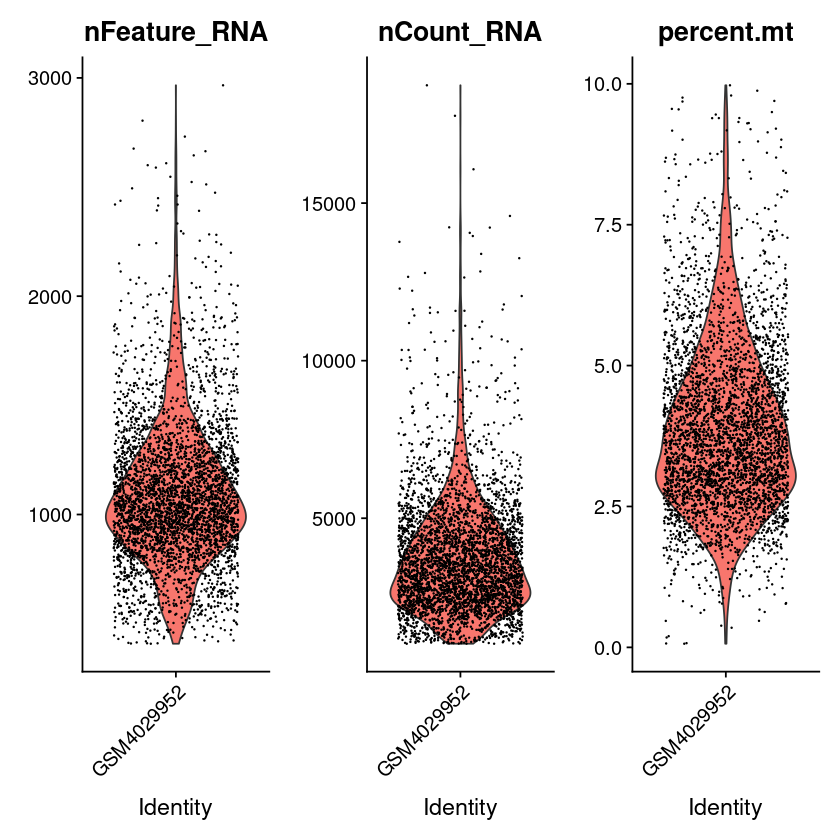

In [6]:
# Calculate mitochondrial percentage
seurat_obj_filtered[["percent.mt"]] <- PercentageFeatureSet(seurat_obj_filtered, pattern = "^MT-")

# Calculate ribosomal percentage (optional)
seurat_obj_filtered[["percent.ribo"]] <- PercentageFeatureSet(seurat_obj_filtered, pattern = "^RP[SL]")

# Visualize QC metrics
VlnPlot(seurat_obj_filtered, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)

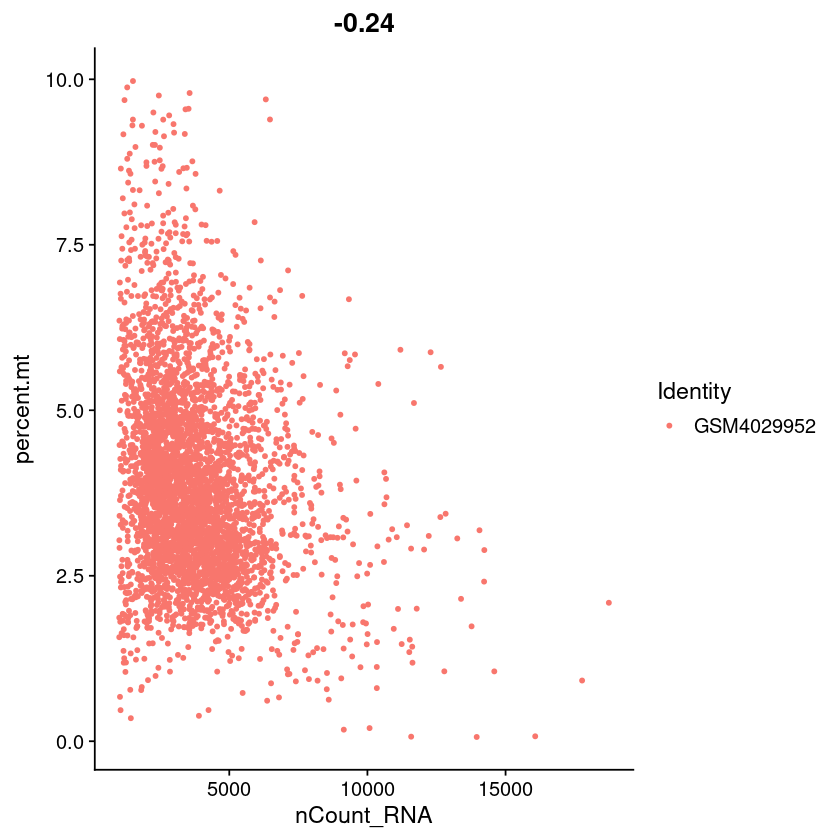

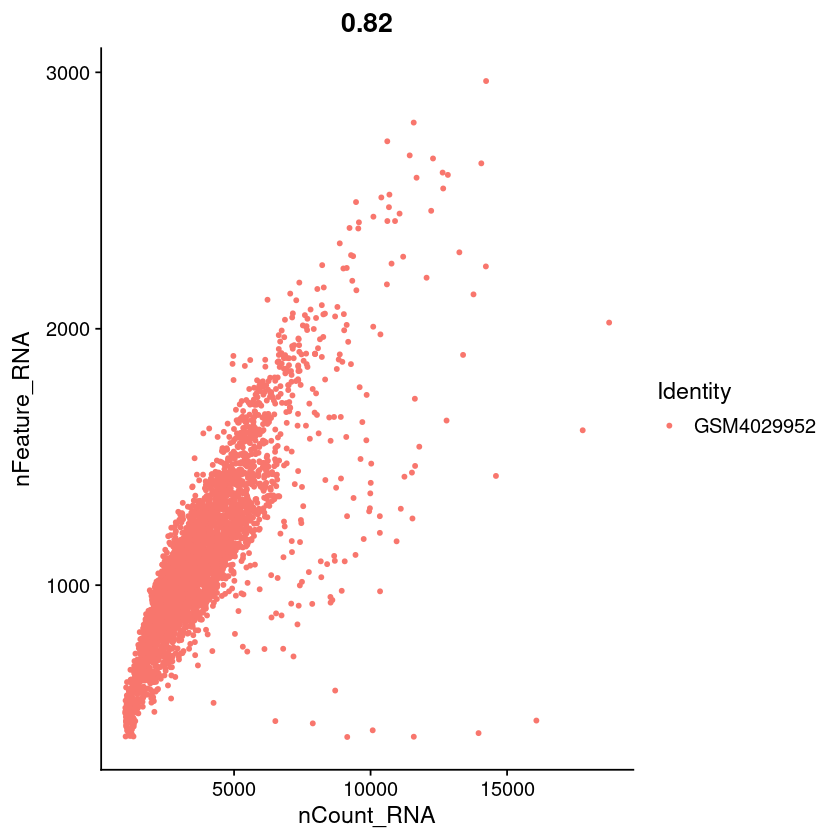

In [9]:
# FeatureScatter is typically used to visualize feature-feature relationships, but can be used
# for anything calculated by the object, i.e. columns in object metadata, PC scores etc.

plot1 <- FeatureScatter(seurat_obj_filtered, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot2 <- FeatureScatter(seurat_obj_filtered, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
plot1
plot2

In [8]:
VlnPlot(sample, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)


ERROR: Error in UseMethod(generic = "DefaultAssay", object = object): no applicable method for 'DefaultAssay' applied to an object of class "function"
